# Project: Harry Potter characters

The ideas of our analysis is to discover/ do some interessting findings about the Harry Potter Universe and the relationships between the characters. We want to better understand the Wizarding World and see if some intuations are confirmes by a graph analysis. 
The main questions we want to awnser are:
* Do the number of citation in the books of each character really reflects its centrality in the universe.
* Are the Hogward houses a good way to split the characters?: do they form good communities? Does the vocabulary associated with the characters of each houses relfects the "values" of each houses? Which houses have the most positive vocabulary?
* Are Blood-Status a better way to split the Harry Potter characters? Do they form good communities?
* Most of the characters of Harry Potter universe can by said as "good" or "bad". If we spleet all the characters that way, who is the most "neutral" character (most balanced good/bad links ratio)? And can this measure be associated with any kind of centrality?

This notebook will be spet in 5 parts:

1. Download of the data and construction of the network
2. Basic Statistics about the Network
3. Number of citations
4. Hogward Houses text (TF_IDF and sentiment)
5. Communities (Hogward houses, Blood-Status or neither)
6. Most neutral character

## 1. Download of the data and construction of the network

* First we have looked for the most complete and large list of Harry Potter character we could find online (https://beyondhogwarts.com/harry-potter/books/character-list/)
* Then, manually we have constructed the txt file containing the list of all characters. We took all the chracters of this online list and checked what was the title of its corresponding fandom wiki page (https://harrypotter.fandom.com/wiki/{name}).
* In another notebook, we go through every names in this list and for each character we open the associated fandom wiki page's wikitext and create a local file to store the wikitext in a .txt file.
* To have all the wikitext accessible simply (without creating all the local files everytime), we pushed all the wikitext files as well as the hole list of characters name on our public github (https://github.com/EricBrevilliers/Harry_Potter_Graph)
* In the next cell, we go through the list of names on github to retrieve a list of character names.

In [1]:
# Go through the list of names on github to retrieve a list of character names
import urllib.request
import requests

# Read the file with the wikitext of the harry_Potter_characters list and extract the names
url_list = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/list_characters/harry_Potter_characters.txt"

response_list = requests.get(url_list)
names = [] # Initialize the list

if response_list.status_code == 200:
    content_list = response_list.text
    # We divide the string "content_list" in a list (one string/name per line)
    names = content_list.splitlines()
    
    # Ensure that there is no empty name
    names = [name for name in names if name.strip()]
    names = sorted(list(set(names)))
    print(f"Found {len(names)} names.")
else:
    print(f"Error retrieving file: {response_list.status_code}")

Found 412 names.


* In the next cell, we go through every characters previously added in the list and make each of them being a node. For all the characters we also search in the github the associated wikitext and use it to add a ***word_count* attribute** to each node and to add the edges.

In [12]:
# Go through every wikitext we have already saved in our github and construct the graph

import requests
import networkx as nx
import re

HpGraph = nx.DiGraph()
name_set = set(names)
names_clean = [name.replace('_', ' ').replace('%27', "'") for name in names] # clean more lisible names
names_url   = [name.replace('%27', '%2527') for name in names] # repcise name for the url

raw_to_clean = dict(zip(names, names_clean)) # Ex: raw_to_clean["Harry_Potter"] -> "Harry Potter"
raw_to_url   = dict(zip(names, names_url)) # Ex: raw_to_clean["Hermione_Granger%27s_mother"] -> "Hermione_Granger%2527s_mother"

print(f"Building graph from {len(names)} characters...")

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
    
        # Adds the node and the word_count attribute
        words = re.findall(r'\b\w+\b', content)
        word_count = len(words)
        HpGraph.add_node(name_clean, word_count=word_count)

        # Finds everything between [[ and the first |, #, or ]
        links = re.findall(r'\[\[([^\]\|#]+)', content)

        # Loop over all found links
        for link in links:
            # Filter to ignore 'File:', 'Category:', 'Image:', etc.
            if ':' in link:
                continue
            
            link_clean = link.strip().replace(' ', '_').replace("'", "%27")
            
            # We check if the normalized link is in our 'name_set'
            if link_clean in name_set:
                # Avoid a node pointing to itself
                if name != link_clean:
                    HpGraph.add_edge(name_clean, link)
    else:
        # It's normal to have some errors if a file was not
        # correctly saved or if the name has a typo
        print(f"[Warning] Failed to load: {name} (Status: {response.status_code})")

print(f"Graph construction complete. {HpGraph.number_of_nodes()} nodes added, {HpGraph.number_of_edges()} edges created.")

Building graph from 412 characters...
Graph construction complete. 412 nodes added, 6928 edges created.


* In the next cell we filter the newtowrk node to remove the isolated nodes

In [38]:
# Identify isolated nodes and remove them
nodes_to_remove = []
for node in HpGraph.nodes():
    if HpGraph.in_degree(node) == 0 and HpGraph.out_degree(node) == 0:
        nodes_to_remove.append(node)
        
HpGraph_noIsolatedNodes = HpGraph.copy()
HpGraph_noIsolatedNodes.remove_nodes_from(nodes_to_remove)
print(f"{len(nodes_to_remove)} isolated nodes deleted. {HpGraph_noIsolatedNodes.number_of_nodes()} nodes still in network.")

21 isolated nodes deleted. 391 nodes still in network.


* In the next cell we filter the network to only keep the larger connected component and we build the "twin" undirected graph.

In [128]:
# Finds the connected component and keeps the largest
weakly_connected_components = list(nx.weakly_connected_components(HpGraph))

if weakly_connected_components:
    largest_component = max(weakly_connected_components, key=len)
    HpGraph_connected = HpGraph.subgraph(largest_component).copy()
else:
    HpGraph_connected = HpGraph.copy()

print(f"Largest connected component contains {HpGraph_connected.number_of_nodes()} nodes")

HpGraph_undir = HpGraph_connected.to_undirected()

Largest connected component contains 387 nodes


## 2. Basic Statistics about the Network

### 2.1 First network information

#### 2.1.1 Basic Network information

In this section, we compute the most fundamental characteristics of the graph, including:
- The total number of nodes (characters)  
- The total number of edges (links between characters)  
- The density of the directed network

These metrics provide a first overview of how connected the Harry Potter character graph is.

In [5]:
# Basic Network Statistics: nodes, edges, density

# Get the number of nodes and edges
num_nodes = HpGraph_connected.number_of_nodes()
num_edges = HpGraph_connected.number_of_edges()

print("--- Basic Network Stats ---")
print(f"Nodes (Characters): {num_nodes}")
print(f"Edges (Links): {num_edges}")

# Density of a directed graph: edges / (N*(N-1))
# Calculate density, rounding to 4 decimals
if num_nodes > 1:
    max_possible_edges = num_nodes * (num_nodes - 1)
    density = num_edges / max_possible_edges
    print(f"Density: {density:.4f}")
else:
    print("Density: N/A")


--- Basic Network Stats ---
Nodes (Characters): 387
Edges (Links): 6924
Density: 0.0464


#### 2.1.2 Degree Statistic

To gain a deeper understanding of the structure of the Harry Potter character graph, we now compute:

- The **average in-degree** (how many characters link *to* a character)  
- The **average out-degree** (how many characters a character links *to*)  
- The **maximum in-degree**, and which character(s) receive the most links  
- The **maximum out-degree**, and which character(s) create the most links  

These metrics highlight the most central and influential characters in the network based on direct hyperlink connections.

In [6]:
#Compute in-degree and out-degree statistics

# Get dictionaries of degrees {node: degree}
in_degrees_dict = dict(HpGraph_connected.in_degree())
out_degrees_dict = dict(HpGraph_connected.out_degree())

# Calculate averages
avg_in = sum(in_degrees_dict.values()) / num_nodes
avg_out = sum(out_degrees_dict.values()) / num_nodes  # Note: avg_in and avg_out must be equal

# Find max values
max_in = max(in_degrees_dict.values())
max_out = max(out_degrees_dict.values())

# Find the characters with those max values
max_in_nodes = [node for node, deg in in_degrees_dict.items() if deg == max_in]
max_out_nodes = [node for node, deg in out_degrees_dict.items() if deg == max_out]

print(f"--- Degree Statistics ---")
print(f"Average in-degree: {avg_in:.4f}")
print(f"Average out-degree: {avg_out:.4f}")

print(f"\nMaximum in-degree: {max_in}")
print(f"Character(s) with maximum in-degree:")
for node in max_in_nodes:
    print(f"  - {node}")

print(f"\nMaximum out-degree: {max_out}")
print(f"Character(s) with maximum out-degree:")
for node in max_out_nodes:
    print(f"  - {node}")

--- Degree Statistics ---
Average in-degree: 17.8915
Average out-degree: 17.8915

Maximum in-degree: 280
Character(s) with maximum in-degree:
  - Harry Potter

Maximum out-degree: 168
Character(s) with maximum out-degree:
  - Harry Potter


The average in-degree and out-degree are both 17.8915, meaning a typical character page links to (or is linked by) about 18 other characters. This equality is expected in a directed graph.

Unsurprisingly, the character with the highest in-degree (280 links received) and the highest out-degree (168 links made) is **Harry Potter**, confirming his central role. His page is the most referenced, and it also links out to the widest range of other characters, making him the most structurally central node in the network.

#### 2.1.3 Degree Distributions

In the next cell we plot the distributions of in-degrees and out-degrees to understand how common highly connected characters are.  
These plots help reveal whether the network has a heavy-tailed structure (a few very connected characters and many with few links), which is typical for real-world hyperlink networks.

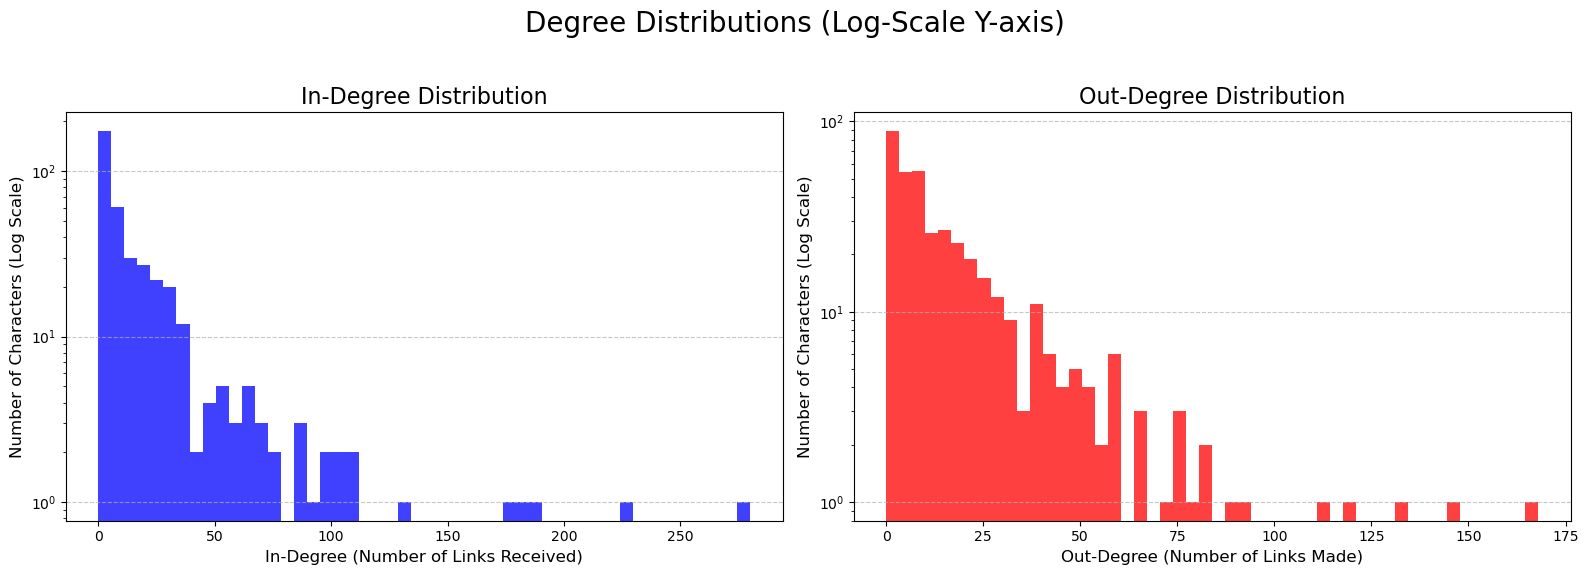

In [7]:
import matplotlib.pyplot as plt

# We already have the degree dictionaries from the previous cells
# in_degrees_dict = dict(HpGraph_connected.in_degree())
# out_degrees_dict = dict(HpGraph_connected.out_degree())

# Get just the degree values for plotting
in_degree_values = list(in_degrees_dict.values())
out_degree_values = list(out_degrees_dict.values())

# Create a figure with two subplots, side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: In-Degree Distribution ---
ax1.hist(in_degree_values, bins=50, alpha=0.75, color='b')
ax1.set_title('In-Degree Distribution', fontsize=16)
ax1.set_xlabel('In-Degree (Number of Links Received)', fontsize=12)
ax1.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax1.set_yscale('log') # Use log scale as requested
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Plot 2: Out-Degree Distribution ---
ax2.hist(out_degree_values, bins=50, alpha=0.75, color='r') 
ax2.set_title('Out-Degree Distribution', fontsize=16)
ax2.set_xlabel('Out-Degree (Number of Links Made)', fontsize=12)
ax2.set_ylabel('Number of Characters (Log Scale)', fontsize=12)
ax2.set_yscale('log') # Use log scale
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Degree Distributions (Log-Scale Y-axis)', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

These histograms show the in-degree (left, blue) and out-degree (right, orange) for our 387-node network. The y-axis is on a log scale to better visualize the long tail.

Both plots show a clear **heavy-tailed distribution**, which is typical for real-world networks. This confirms our earlier finding:
* A vast majority of characters have a very low degree (they are "peripheral" characters).
* A "long tail" of a few, highly-connected nodes (like Harry Potter, Dumbledore, etc.) have a very high degree

### 2.2 Total size of the data 

We use the `word_count` attribute stored on each node and the raw wikitext files to estimate how large our corpus is.

In [8]:
# Total number of words in all character pages in the largest connected component

# Extract the "word_count" attribute for nodes in HpGraph_connected
word_counts = nx.get_node_attributes(HpGraph_connected, "word_count")

total_words = sum(word_counts.values())

print(f"Total number of words in all character pages: {total_words:,d}")

Total number of words in all character pages: 1,592,520


We approximate the total size of all wikitext files by summing the number of bytes downloaded for each character in the largest connected component. We then convert this total to megabytes.

In [9]:
import requests

total_bytes = 0

print(f"Calculating total file size for {HpGraph_connected.number_of_nodes()} nodes...")

for name in HpGraph_connected.nodes():
    
    base_filename = name.replace(" ", "_").replace("'", "%27")
    
    url_filename = base_filename.replace('%27', '%2527')
    
    # This URL now correctly points to the file on GitHub
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{url_filename}.txt"
    
    try:
        response = requests.get(url)
        if response.status_code == 200:
            total_bytes += len(response.content)
    except requests.exceptions.RequestException as e:
        print(f"Warning: Could not fetch {name}")

# Convert bytes to megabytes (using the 1024*1024 )
total_mb = total_bytes / (1024 * 1024)

print(f"\n--- Total File Size (for {HpGraph_connected.number_of_nodes()} nodes) ---")
print(f"Total Bytes: {total_bytes:,d}")
# Format to 4 decimal
print(f"Total Megabytes (MB): {total_mb:.4f} MB")

Calculating total file size for 387 nodes...

--- Total File Size (for 387 nodes) ---
Total Bytes: 9,946,601
Total Megabytes (MB): 9.4858 MB


Our final dataset (the largest connected component of the network) contains:

- **Total text:** 1,592,520 words  
- **Total file size:** approximately 9.486 MB  
- **Number of characters (nodes):** 387  

This text corpus will be used in the remainder of our analysis, both for network–text comparisons and for extracting semantic information from character pages.

## 3. Number of citations

## 4. Hogward houses text

### 4.1 Finding the houses

First, we need to find the Hogward houses of each characters that belongs to one. To do so, we look at the wikipedia infobox of each character and at the "house" line.

In [ ]:
import re
import requests

def get_full_infobox(text):
    """
    Gets the full content fo the infobox by dealing with the interlocking {{...{{...}}...}}
    """
    start_marker = "{{Individual infobox"
    start_index = text.find(start_marker)
    
    if start_index == -1:
        return None
    
    # We start counting after the opening marker
    current_index = start_index
    brace_count = 0
    found_first_open = False
    
    # We go through the text char by char
    # we look for the closing corresponding to the first {{
    for i in range(start_index, len(text)):
        # we look for both char at a time to find {{ or }}
        chunk = text[i:i+2]
        
        if chunk == '{{':
            brace_count += 1
            found_first_open = True
        elif chunk == '}}':
            brace_count -= 1
            
        # If we opened curly braces and returned to 0, that's the end of the infobox.
        if found_first_open and brace_count == 0:
            # We return the entire block (+2 to include the final }}
            return text[start_index:i+2]
            
    return None

def extract_house(file_content):
    """
    Extracts the house only if it is formatted as a wiki link [...]
    """
    
    infobox_content = get_full_infobox(file_content)
    
    if not infobox_content:
        return None

    house_match = re.search(
        r'\|\s*house\s*=\s*\[\[([^|\]]+)', 
        infobox_content, 
        re.IGNORECASE
    )
    
    if house_match:
        return house_match.group(1).strip()
    
    return None

In [ ]:
characters_houses = dict()

for name in name_set:
    name_clean = raw_to_clean[name]
    name_url = raw_to_url[name]
    
    url = f"https://raw.githubusercontent.com/EricBrevilliers/Harry_Potter_Graph/main/wikitext_files/{name_url}.txt"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        content = response.text
        house = extract_house(content)
        
        if house:
            characters_houses[name_clean] = house

In [ ]:
from collections import Counter

all_houses = list(characters_houses.values())

house_counts = Counter(all_houses)

print(f"\n--- Number of characters in each houses (Total: {len(characters_houses)}) ---")

for house, count in house_counts.most_common():
    print(f"{house:<15} : {count}")

As we can see, only 151 out of the 412 characters have a hogward house. Other peaples have none either because their are not well known enough and we don't know their house, because they are wizards that comes from other magic schools or they are not wizards (muggles, fantastic beast, animals, ...).

In this part, we will only keep the nodes that have a house (in ***HpHouseGraph***)

In [ ]:
import networkx as nx

nodes_to_keep = list(characters_houses.keys())

# we create a new graph : HpHouseGraph that keeps only the nodes that belongs to a house.
HpHouseGraph = HpGraph_undir.subgraph(nodes_to_keep).copy()

# in this graph, the nodes have a new attribute: house
nx.set_node_attributes(HpHouseGraph, characters_houses, name="house")

print(f"Original Graph : {HpGraph_connected.number_of_nodes()} nodes, {HpGraph_connected.number_of_edges()} links.")
print(f"New Graph (House only) : {HpHouseGraph.number_of_nodes()} nodes, {HpHouseGraph.number_of_edges()} links.")

## 5. Communities

### 5.1 Louvain communities on the hole network

In [217]:
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpGraph_undir, seed=1)

M_louvain = modularity(HpGraph_undir, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

print("\n--- Membres de chaque communauté ---")

# Utiliser enumerate pour numéroter les communautés
for i, community in enumerate(louvain_commu):
    # La variable 'community' est un ensemble (set) de nœuds
    # On peut trier les membres pour un affichage plus lisible
    members = sorted(list(community))
    
    # Affichage du résumé de la communauté
    print(f"\n🧠 Communauté {i+1} (Taille : {len(members)} membres) :")
    
    # Affichage des membres. Utiliser une jointure pour afficher sur une seule ligne.
    print(f"  {', '.join(members)}")

0.23412391323194004
Nombre de communautés trouvées : 8

--- Membres de chaque communauté ---

🧠 Communauté 1 (Taille : 37 membres) :
  Aberforth Dumbledore, Adalbert Waffling, Albus Dumbledore, Antioch Peverell, Ariana Dumbledore, Armando Dippet, Bathilda Bagshot, Bertie Bott, Betty Braithwaite, Celestina Warbeck, Dilys Derwent, Elphias Doge, Enid Smeek, Everard, Galatea Merrythought, Gellert Grindelwald, Ignotus Peverell, Ivor Dillonsby, Kendra Dumbledore, Lorcan Scamander, Lysander Scamander, Muriel, Mykew Gregorovitch, Newton Scamander, Nicolas Flamel, Percival Dumbledore, Perenelle Flamel, Phineas Nigellus Black, Rita Skeeter, Rolf Scamander, S. Fawcett, Scorpius Malfoy, Silvanus Kettleburn, Stebbins (1970s Hogwarts student), Stebbins (1990s Hogwarts student), Stebbins (Auror), Xenophilius Lovegood

🧠 Communauté 2 (Taille : 78 membres) :
  Alberic Grunnion, Ambrosius Flume, Amy Benson, Aragog, Arnold Peasegood, Bane, Barnabas Cuffe, Basil, Bertie Higgs, Blaise Zabini, Bloody Baron,

The communities are not good enougth (< 0.3), let's try to do it with filtered edges

As we can see, only 151 out of the 412 characters have a hogward house. Other peaples have none either because their are not well known enough and we don't know their house, because they are wizards that comes from other magic schools or they are not wizards (muggles, fantastic beast, animals, ...).

In this part, we will only keep the nodes that have a house (in ***HpHouseGraph***)

In [130]:
def modularity(G, communities):
    # The number of link L in the graph
    L = len(G.edges())
    # the number of communities
    n_c = len(communities)
    # the number of links in each community L_c
    L_c = [0] * n_c
    # The sum of degrees of the nodes in each communities
    k_c = [0] * n_c
    
    for i in range(0,len(communities)):
        community = communities[i]

        # Compute k_c
        for node in community:
            k_c[i] += G.degree[node]

    # Compute L_c
    for i, community in enumerate(communities):
        for node1, node2 in G.edges():
            if node1 in community and node2 in community:
                L_c[i] += 1
    
    M = 0
    for c in range(n_c):
        M += L_c[c] / L - pow(k_c[c] / (2 * L), 2)
    return M

# we need to construct the dictionary: house -> set(characters)
house_to_character = {}
for character in HpHouseGraph.nodes():
    house = characters_houses[character]

    if(house not in house_to_character.keys()):
        house_to_character[house] = set()

    house_to_character[house].add(character)

M = modularity(HpHouseGraph, list(house_to_character.values()))
print(M)

0.06802202246919688


In [215]:
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(HpHouseGraph, seed=6)

M_louvain = modularity(HpHouseGraph, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

0.1771647278281185
Nombre de communautés trouvées : 5


In [212]:
print("\n--- Membres de chaque communauté ---")

# Utiliser enumerate pour numéroter les communautés
for i, community in enumerate(louvain_commu):
    # La variable 'community' est un ensemble (set) de nœuds
    # On peut trier les membres pour un affichage plus lisible
    members = sorted(list(community))
    
    # Affichage du résumé de la communauté
    print(f"\n🧠 Communauté {i+1} (Taille : {len(members)} membres) :")
    
    # Affichage des membres. Utiliser une jointure pour afficher sur une seule ligne.
    print(f"  {', '.join(members)}")


--- Membres de chaque communauté ---

🧠 Communauté 1 (Taille : 41 membres) :
  Albus Potter, Alphard Black, Andromeda Tonks, Araminta Meliflua Black, Arthur Weasley, Avery I, Avery II, Bellatrix Lestrange, Charles Weasley, Draco Malfoy, Edward Lupin, Evan Rosier, Garrick Ollivander, Horace Slughorn, James Potter (I), James Potter (II), Lily Potter (I), Lily Potter (II), Lucius Malfoy, Miles Bletchley, Millicent Bagnold, Molly Weasley, Mulciber II, Narcissa Malfoy, Nymphadora Tonks, Percy Weasley, Peter Pettigrew, Phineas Nigellus Black, Rabastan Lestrange, Regulus Black, Remus Lupin, Rodolphus Lestrange (II), Rose Granger-Weasley, Rubeus Hagrid, Scabior, Scorpius Malfoy, Severus Snape, Sirius Black, Tom Riddle, Walburga Black, William Weasley

🧠 Communauté 2 (Taille : 32 membres) :
  Alicia Spinnet, Andrew Kirke, Angelina Johnson, Anthony Goldstein, Cedric Diggory, Cho Chang, Colin Creevey, Dean Thomas, Dennis Creevey, Dolores Umbridge, Ernest Macmillan, Fred Weasley, George Weasley, 

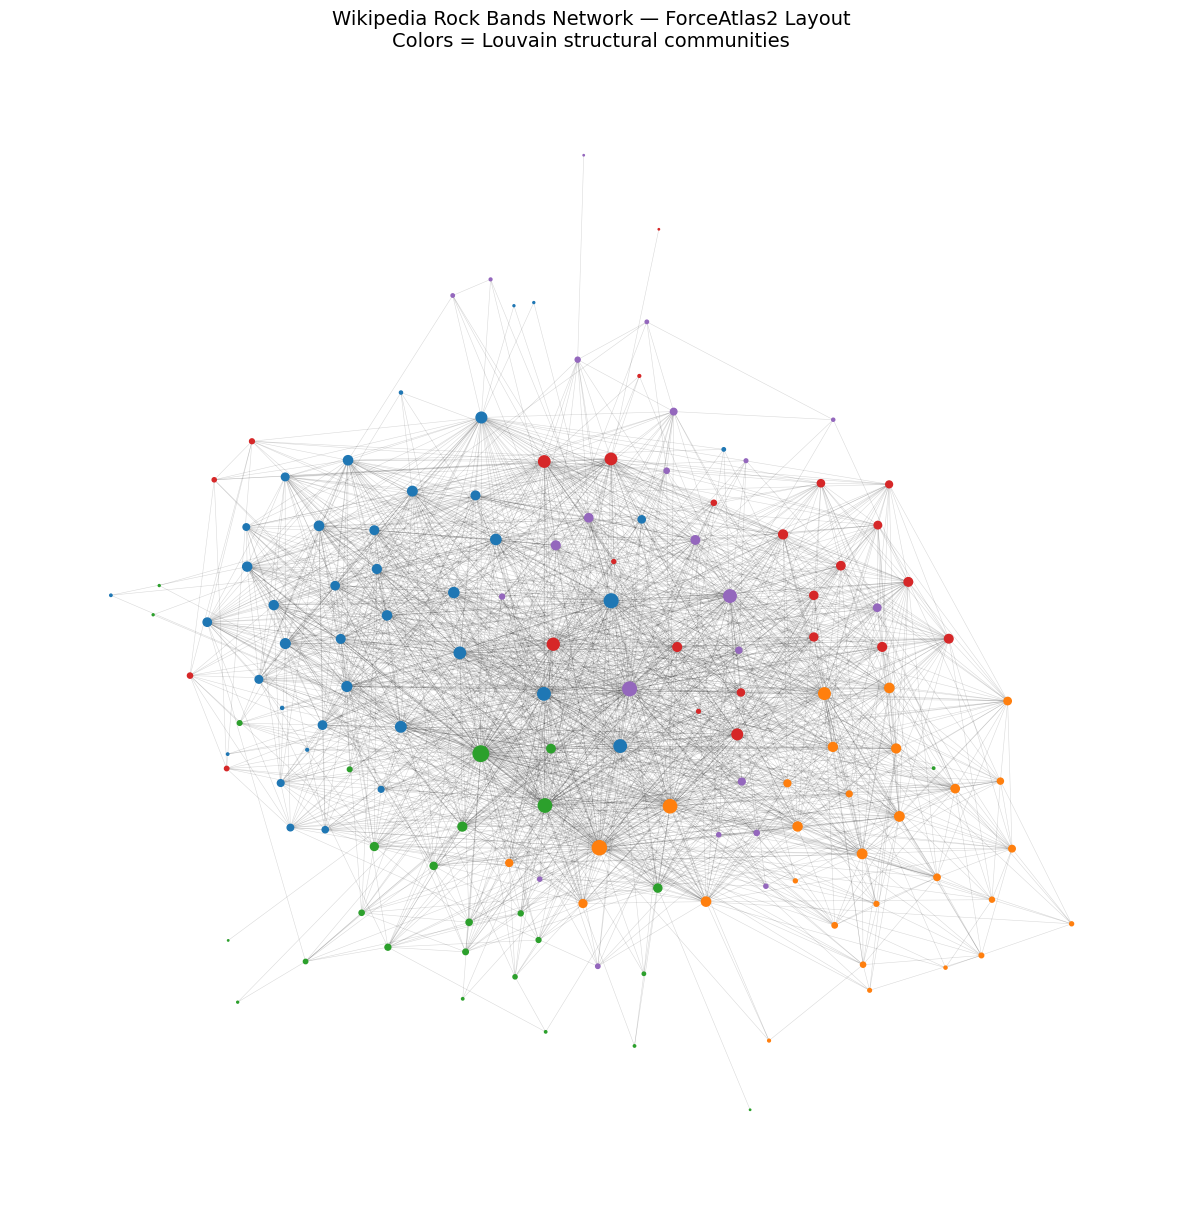

In [132]:
import matplotlib.pyplot as plt
import numpy as np

def color_choice(louvain_commu):
    # --- Sélection des plus grandes communautés ---
    sorted_comms = sorted(louvain_commu, key=len, reverse=True)
    top_k = 10  # on garde les 10 plus grandes
    top_comms = sorted_comms[:top_k]
    
    # Création d’un mapping node -> couleur
    color_map = {}
    colors = plt.cm.tab10.colors  # palette avec 10 couleurs distinctes
    for i, comm in enumerate(top_comms):
        for node in comm:
            color_map[node] = colors[i % len(colors)]
    
    # Les autres (petites communautés) seront gris clair
    for comm in sorted_comms[top_k:]:
        for node in comm:
            color_map[node] = (0.8, 0.8, 0.8)  # gris neutre

    return color_map

# --- Taille des nœuds proportionnelle au degré ---
node_sizes = [HpHouseGraph.degree(n) for n in HpHouseGraph.nodes()]

# --- Positionnement avec ForceAtlas2 ---
pos = nx.forceatlas2_layout(
    HpHouseGraph,
    max_iter=300,
    scaling_ratio=1.0,
    gravity=1.0,
    jitter_tolerance=1.0
)

# --- Couleurs des nœuds ---
color_map = color_choice(louvain_commu)
node_colors = [color_map[n] for n in HpHouseGraph.nodes()]

# --- Affichage ---
plt.figure(figsize=(15, 15))
nx.draw_networkx_edges(HpHouseGraph, pos, alpha=0.15, width=0.4, edge_color="black")
nx.draw_networkx_nodes(
    HpHouseGraph, pos,
    node_size=node_sizes,
    node_color=node_colors
)

plt.title("Wikipedia Rock Bands Network — ForceAtlas2 Layout\nColors = Louvain structural communities", fontsize=14)
plt.axis("off")
plt.show()

**The louvain algorithm gives bad result, we try to filter with the inverse propostional to the edge betweenness to have better modularity). It gives better modularity results but it feels strange ans does not reflect the network anymore**

In [197]:
# Weighted Network 2
Hp_inverse_betweenness_weights = HpHouseGraph.copy()

# We get the min and max edge betweenness
edge_beteweenness = dict(nx.edge_betweenness_centrality(HpHouseGraph))
min_edge_betweenness = edge_beteweenness.get(min(edge_beteweenness, key= lambda x: edge_beteweenness.get(x)))
max_edge_betweenness = edge_beteweenness.get(max(edge_beteweenness, key= lambda x: edge_beteweenness.get(x)))

# Creates the graph with edges with correponding weights
for edge, b_value in edge_beteweenness.items():
    p = (b_value - min_edge_betweenness) / (max_edge_betweenness - min_edge_betweenness)
    weight = 99 * p + 1
    Hp_inverse_betweenness_weights[edge[0]][edge[1]]['inv_btwss_weight'] = 1 / weight

In [198]:
def disparity_filter(table, undirected = False, return_self_loops = False):
   sys.stderr.write("Calculating DF score...\n")
   table = table.copy()
   table_sum = table.groupby(table["src"]).sum().reset_index()
   table_deg = table.groupby(table["src"]).count()["trg"].reset_index()
   table = table.merge(table_sum, on = "src", how = "left", suffixes = ("", "_sum"))
   table = table.merge(table_deg, on = "src", how = "left", suffixes = ("", "_count"))
   table["score"] = 1.0 - ((1.0 - (table["nij"] / table["nij_sum"])) ** (table["trg_count"] - 1))
   table["variance"] = (table["trg_count"] ** 2) * (((20 + (4.0 * table["trg_count"])) / ((table["trg_count"] + 1.0) * (table["trg_count"] + 2) * (table["trg_count"] + 3))) - ((4.0) / ((table["trg_count"] + 1.0) ** 2)))
   if not return_self_loops:
      table = table[table["src"] != table["trg"]]
   if undirected:
      table["edge"] = table.apply(lambda x: "%s-%s" % (min(x["src"], x["trg"]), max(x["src"], x["trg"])), axis = 1)
      table_maxscore = table.groupby(by = "edge")["score"].max().reset_index()
      table_minvar = table.groupby(by = "edge")["variance"].min().reset_index()
      table = table.merge(table_maxscore, on = "edge", suffixes = ("_min", ""))
      table = table.merge(table_minvar, on = "edge", suffixes = ("_max", ""))
      table = table.drop_duplicates(subset = ["edge"])
      table = table.drop("edge", axis=1)
      table = table.drop("score_min", axis=1)
      table = table.drop("variance_max", axis=1)
   return table[["src", "trg", "nij", "score", "variance"]]

In [205]:
import pandas as pd
import sys

def graph_to_table(G, weight_attr):
    return pd.DataFrame([
        {"src": u, "trg": v, "nij": G[u][v][weight_attr]}
        for u, v in G.edges()
    ])

# Weighted Network 2
table2 = graph_to_table(Hp_inverse_betweenness_weights, "inv_btwss_weight")
df_table2 = disparity_filter(table2, undirected=True)
alpha2 = 0.35
df_backbone2 = df_table2[df_table2['score'] <= alpha2]  
G_df2 = nx.from_pandas_edgelist(df_backbone2, source="src", target="trg", edge_attr="score", create_using=nx.Graph())

Calculating DF score...


In [206]:
from networkx.algorithms.community import louvain_communities

louvain_commu = louvain_communities(G_df2, seed=9)

M_louvain = modularity(G_df2, louvain_commu)
print(M_louvain)
num_commu = len(louvain_commu)
print(f"Nombre de communautés trouvées : {num_commu}")

0.41173357582623993
Nombre de communautés trouvées : 9


In [210]:
print("\n--- Membres de chaque communauté ---")

# Utiliser enumerate pour numéroter les communautés
for i, community in enumerate(louvain_commu):
    # La variable 'community' est un ensemble (set) de nœuds
    # On peut trier les membres pour un affichage plus lisible
    members = sorted(list(community))
    
    # Affichage du résumé de la communauté
    print(f"\n🧠 Communauté {i+1} (Taille : {len(members)} membres) :")
    
    # Affichage des membres. Utiliser une jointure pour afficher sur une seule ligne.
    print(f"  {', '.join(members)}")


--- Membres de chaque communauté ---

🧠 Communauté 1 (Taille : 35 membres) :
  Adrian Pucey, Cassius Warrington, Cedric Diggory, Dean Thomas, Eloise Midgen, Euan Abercrombie, Garrick Ollivander, Hannah Abbott, Harper, Harry Potter, Hengist of Woodcroft, James Potter (I), Lavender Brown, Lee Jordan, Lisa Turpin, Mandy Brocklehurst, Millicent Bulstrode, Morag MacDougal, Myrtle Warren, Oliver Wood, Padma Patil, Pansy Parkinson, Parvati Patil, Percy Weasley, Peter Pettigrew, Pomona Sprout, Quirinus Quirrell, Rabastan Lestrange, Remus Lupin, Roger Davies, Salazar Slytherin, Sally-Anne Perks, Seamus Finnigan, Susan Bones, Sybill Trelawney

🧠 Communauté 2 (Taille : 12 membres) :
  Anthony Goldstein, Cadogan, Cormac McLaggen, Godric Gryffindor, Helena Ravenclaw, Natalie McDonald, Nicholas de Mimsy-Porpington, Phineas Nigellus Black, Regulus Black, Ronald Weasley, Scorpius Malfoy, Vicky Frobisher

🧠 Communauté 3 (Taille : 12 membres) :
  Albus Dumbledore, Celestina Warbeck, Ernest Prang, Gilde

In [207]:
print(len(G_df2.nodes()))
print(len(G_df2.edges()))

130
259


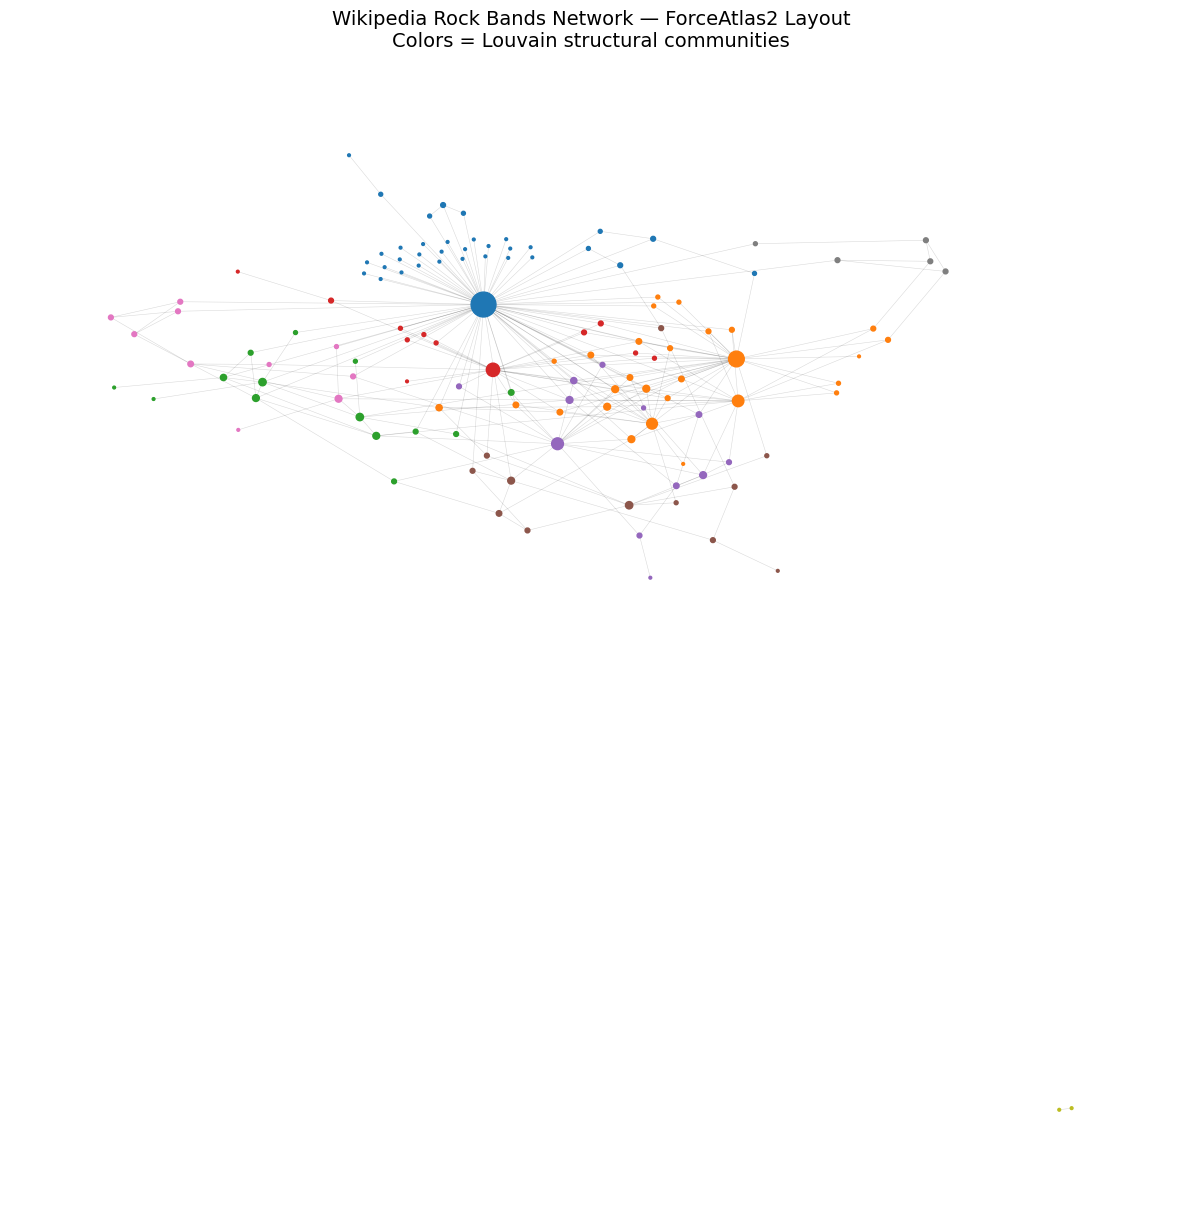

In [208]:
import matplotlib.pyplot as plt
import numpy as np

def color_choice(louvain_commu):
    # --- Sélection des plus grandes communautés ---
    sorted_comms = sorted(louvain_commu, key=len, reverse=True)
    top_k = 10  # on garde les 10 plus grandes
    top_comms = sorted_comms[:top_k]
    
    # Création d’un mapping node -> couleur
    color_map = {}
    colors = plt.cm.tab10.colors  # palette avec 10 couleurs distinctes
    for i, comm in enumerate(top_comms):
        for node in comm:
            color_map[node] = colors[i % len(colors)]
    
    # Les autres (petites communautés) seront gris clair
    for comm in sorted_comms[top_k:]:
        for node in comm:
            color_map[node] = (0.8, 0.8, 0.8)  # gris neutre

    return color_map

# --- Taille des nœuds proportionnelle au degré ---
node_sizes = [G_df2.degree(n) * 4 for n in G_df2.nodes()]

# --- Positionnement avec ForceAtlas2 ---
pos = nx.forceatlas2_layout(
    G_df2,
    max_iter=300,
    scaling_ratio=1.0,
    gravity=1.0,
    jitter_tolerance=1.0
)

# --- Couleurs des nœuds ---
color_map = color_choice(louvain_commu)
node_colors = [color_map[n] for n in G_df2.nodes()]

# --- Affichage ---
plt.figure(figsize=(15, 15))
nx.draw_networkx_edges(G_df2, pos, alpha=0.15, width=0.4, edge_color="black")
nx.draw_networkx_nodes(
    G_df2, pos,
    node_size=node_sizes,
    node_color=node_colors
)

plt.title("Wikipedia Rock Bands Network — ForceAtlas2 Layout\nColors = Louvain structural communities", fontsize=14)
plt.axis("off")
plt.show()

## 6. Most neutral character